In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:

# LOAD DATASET

df = pd.read_csv("../Data/segmentation data.csv")


In [4]:
# Display first five records
print(df.head())


          ID  Sex  Marital status  Age  Education  Income  Occupation  \
0  100000001    0               0   67          2  124670           1   
1  100000002    1               1   22          1  150773           1   
2  100000003    0               0   49          1   89210           0   
3  100000004    0               0   45          1  171565           1   
4  100000005    0               0   53          1  149031           1   

   Settlement size  
0                2  
1                2  
2                0  
3                1  
4                1  


In [5]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(2000, 8)


In [6]:
print("\nDataset Information")
print(df.info())




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB
None


In [7]:
print("\nMissing Values")
print(df.isnull().sum())




Missing Values
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


In [8]:
print("\nDescriptive Statistics")
print(df.describe())


Descriptive Statistics
                 ID          Sex  Marital status          Age   Education  \
count  2.000000e+03  2000.000000     2000.000000  2000.000000  2000.00000   
mean   1.000010e+08     0.457000        0.496500    35.909000     1.03800   
std    5.774946e+02     0.498272        0.500113    11.719402     0.59978   
min    1.000000e+08     0.000000        0.000000    18.000000     0.00000   
25%    1.000005e+08     0.000000        0.000000    27.000000     1.00000   
50%    1.000010e+08     0.000000        0.000000    33.000000     1.00000   
75%    1.000015e+08     1.000000        1.000000    42.000000     1.00000   
max    1.000020e+08     1.000000        1.000000    76.000000     3.00000   

              Income   Occupation  Settlement size  
count    2000.000000  2000.000000      2000.000000  
mean   120954.419000     0.810500         0.739000  
std     38108.824679     0.638587         0.812533  
min     35832.000000     0.000000         0.000000  
25%     97663.250

In [9]:

# DATA PREPROCESSING

# Remove Customer ID because it does not contribute to clustering
data = df.drop(columns=["ID"])

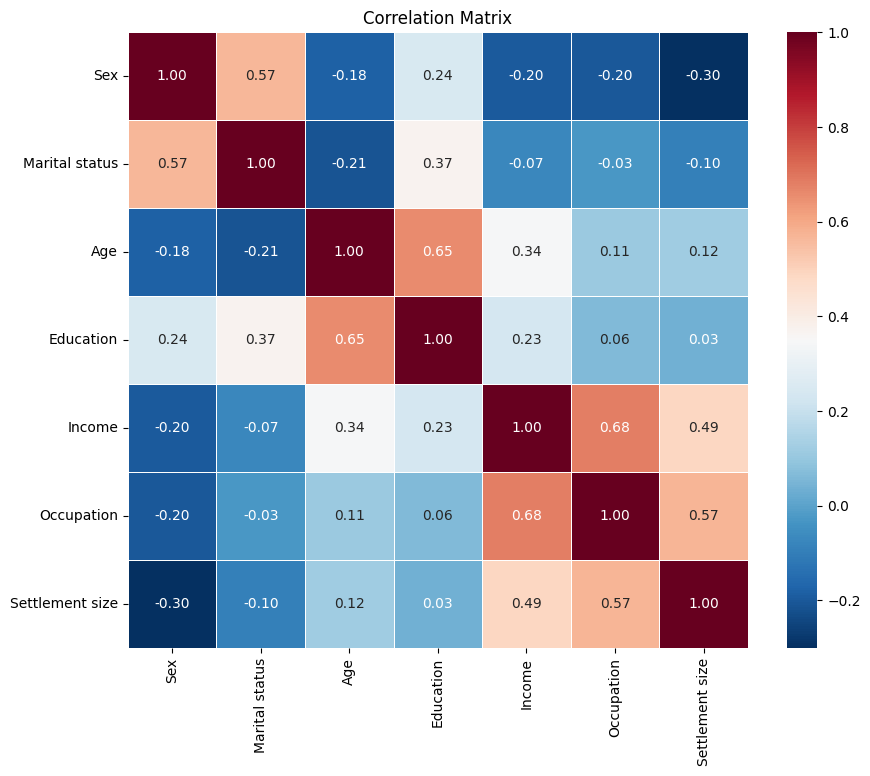

In [10]:
# Correlation Matrix
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    annot=True,
    cmap="RdBu_r",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()



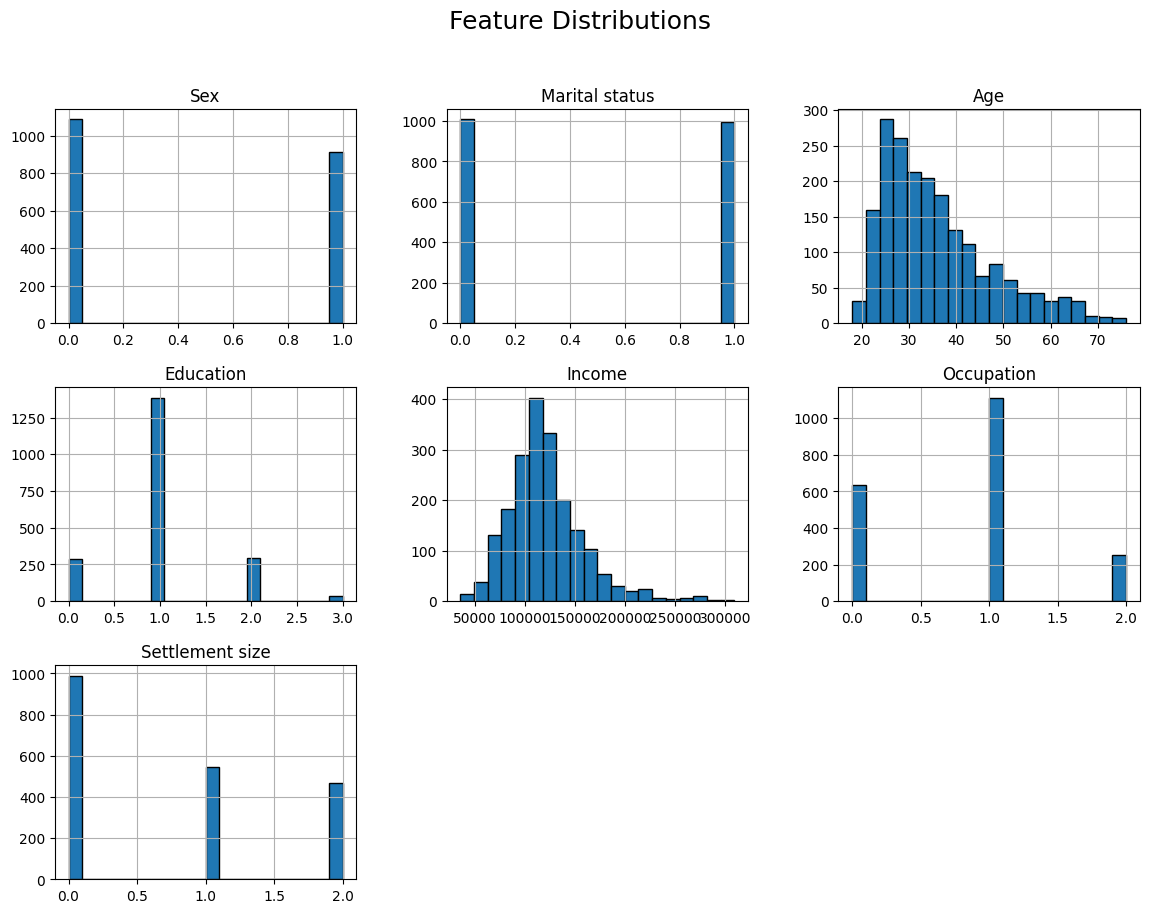

In [11]:
# Distribution of Variables

data.hist(
    figsize=(14,10),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Feature Distributions", fontsize=18)
plt.show()


In [12]:
# FEATURE SCALING


scaler = StandardScaler()

scaled_features = scaler.fit_transform(data)

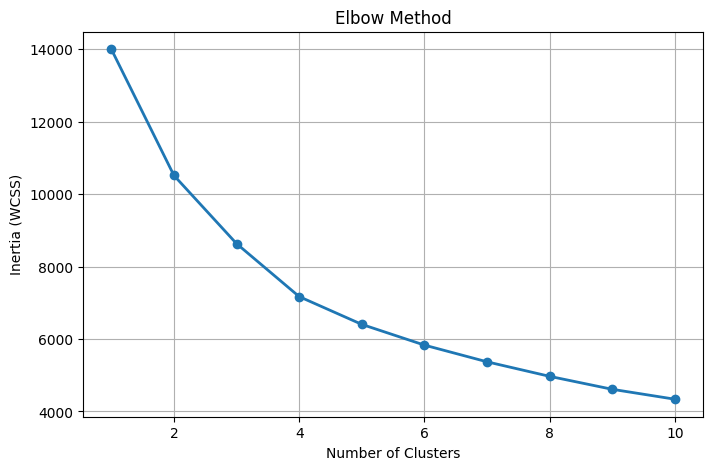

In [13]:
# DETERMINE OPTIMAL NUMBER OF CLUSTERS

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o',
    linewidth=2
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)

plt.show()

In [14]:
# SILHOUETTE SCORE

print("Silhouette Scores\n")

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_features)

    score = silhouette_score(
        scaled_features,
        labels
    )

    print(f"{k} Clusters : {score:.4f}")


Silhouette Scores

2 Clusters : 0.2498
3 Clusters : 0.2712
4 Clusters : 0.2688
5 Clusters : 0.2542
6 Clusters : 0.2632
7 Clusters : 0.2653
8 Clusters : 0.2870
9 Clusters : 0.3042
10 Clusters : 0.3014


In [15]:
# BUILD FINAL MODEL

optimal_clusters = 4

kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_features)

data["Cluster"] = cluster_labels



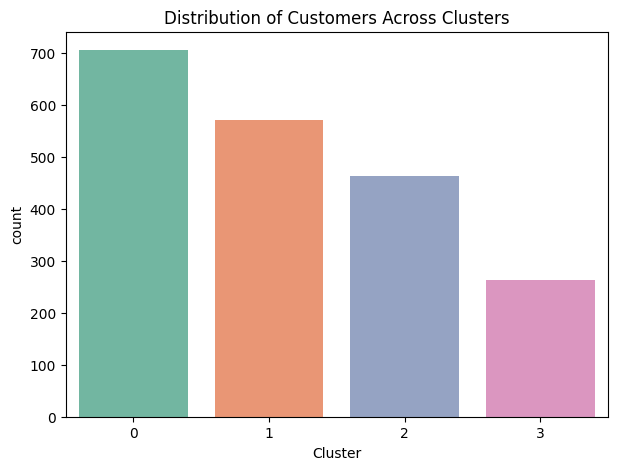

In [16]:

# CLUSTER DISTRIBUTION

plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=data,
    palette="Set2"
)

plt.title("Distribution of Customers Across Clusters")

plt.show()



In [17]:

# CLUSTER PROFILE

cluster_profile = data.groupby("Cluster").mean()

print("\nCluster Profile")
print(cluster_profile)




Cluster Profile
              Sex  Marital status        Age  Education         Income  \
Cluster                                                                  
0        0.853901        0.997163  28.963121   1.068085  105759.119149   
1        0.029825        0.173684  35.635088   0.733333  141218.249123   
2        0.352814        0.019481  35.577922   0.746753   97859.852814   
3        0.501901        0.692015  55.703422   2.129278  158338.422053   

         Occupation  Settlement size  
Cluster                               
0          0.634043         0.422695  
1          1.271930         1.522807  
2          0.329004         0.043290  
3          1.129278         1.110266  


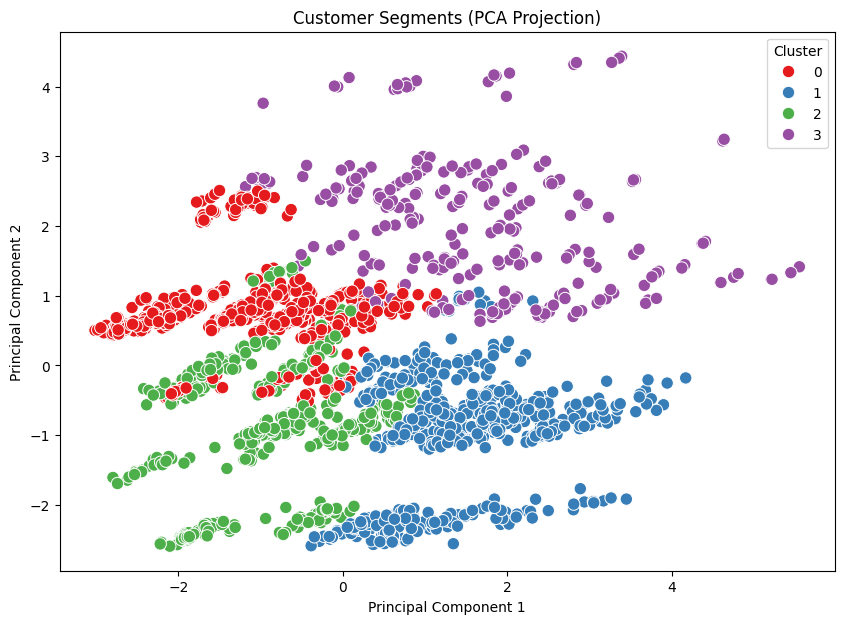

In [18]:

# PCA VISUALIZATION

pca = PCA(n_components=2)

principal_components = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = cluster_labels

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title("Customer Segments (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()



In [19]:

# CLUSTER CENTERS

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=data.columns[:-1]
)

print("\nCluster Centroids")
print(centroids.round(2))




Cluster Centroids
    Sex  Marital status    Age  Education     Income  Occupation  \
0  0.85            1.00  28.96       1.07  105759.12        0.63   
1  0.03            0.17  35.64       0.73  141218.25        1.27   
2  0.35            0.02  35.58       0.75   97859.85        0.33   
3  0.50            0.69  55.70       2.13  158338.42        1.13   

   Settlement size  
0             0.42  
1             1.52  
2             0.04  
3             1.11  


In [20]:

# SAVE RESULTS

results = df.copy()
results["Cluster"] = cluster_labels

results.to_csv(
    "Customer_Segmentation_Results.csv",
    index=False
)

print("\nCustomer segmentation completed successfully.")


Customer segmentation completed successfully.
